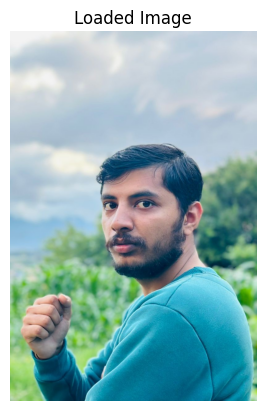

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# ✅ Use a working direct image URL
url = "https://i.imgur.com/iyjjBpF.jpeg"

# Add headers (important fix)
headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

# Check if request worked
if response.status_code == 200:
    try:
        img = Image.open(BytesIO(response.content))
        plt.imshow(img)
        plt.axis('off')
        plt.title("Loaded Image")
        plt.show()
    except Exception as e:
        print("Error opening image:", e)
else:
    print("Failed to fetch image. Status code:", response.status_code)

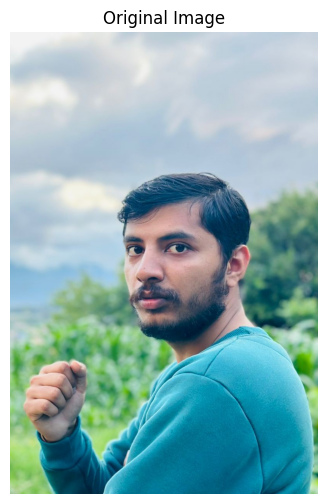

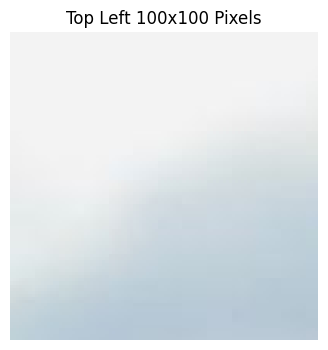

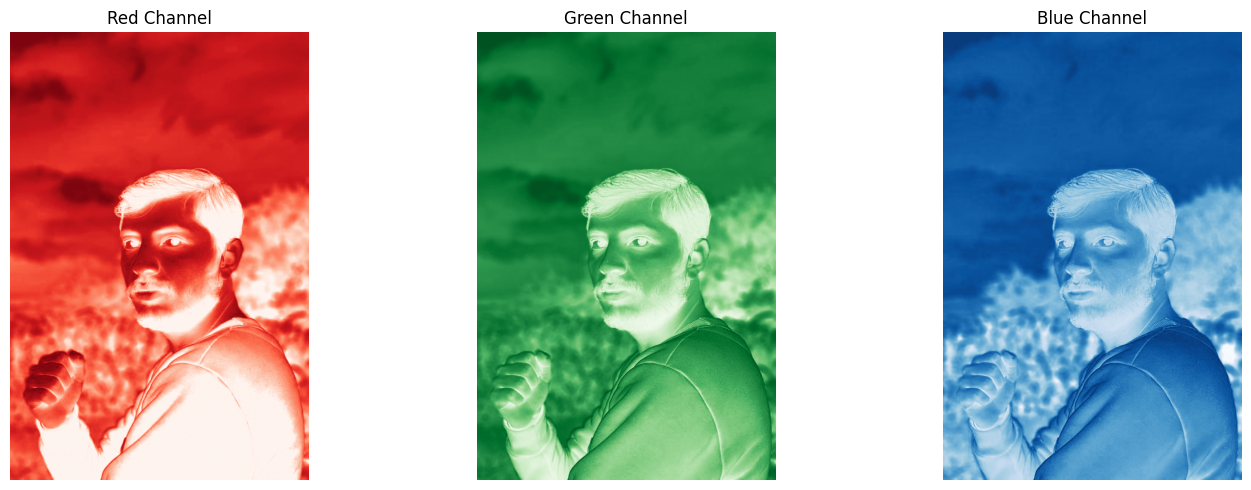

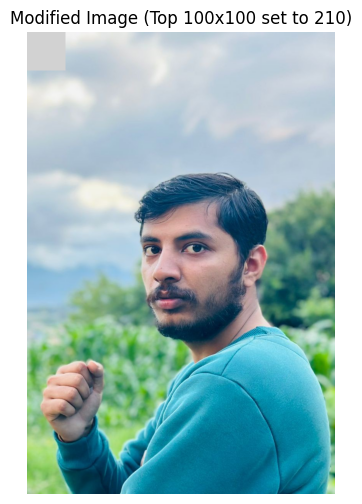

In [8]:
# Exercise 1: Image Processing Tasks

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO

# ------------------ LOAD IMAGE FROM URL ------------------
url = "https://i.imgur.com/iyjjBpF.jpeg"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

if response.status_code == 200:
    try:
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img_array = np.array(img)

        # ------------------ TASK 1: READ AND DISPLAY IMAGE ------------------
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title("Original Image")
        plt.axis('off')
        plt.show()

        # ------------------ TASK 2: DISPLAY TOP LEFT 100x100 ------------------
        top_left = img_array[:100, :100]

        plt.figure(figsize=(4, 4))
        plt.imshow(top_left)
        plt.title("Top Left 100x100 Pixels")
        plt.axis('off')
        plt.show()

        # ------------------ TASK 3: SHOW RGB CHANNELS ------------------
        R = img_array[:, :, 0]
        G = img_array[:, :, 1]
        B = img_array[:, :, 2]

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(R, cmap='Reds')
        plt.title("Red Channel")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(G, cmap='Greens')
        plt.title("Green Channel")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(B, cmap='Blues')
        plt.title("Blue Channel")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

        # ------------------ TASK 4: MODIFY TOP 100x100 TO 210 ------------------
        modified_img = img_array.copy()
        modified_img[:100, :100] = 210

        plt.figure(figsize=(6, 6))
        plt.imshow(modified_img)
        plt.title("Modified Image (Top 100x100 set to 210)")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print("Error opening image:", e)
else:
    print("Failed to fetch image. Status code:", response.status_code)

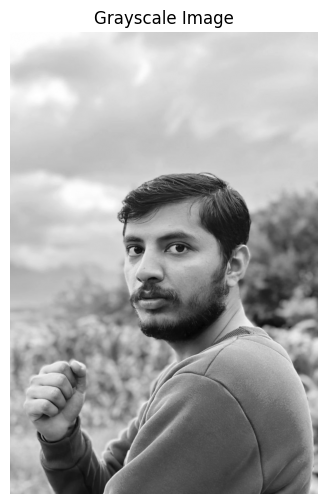

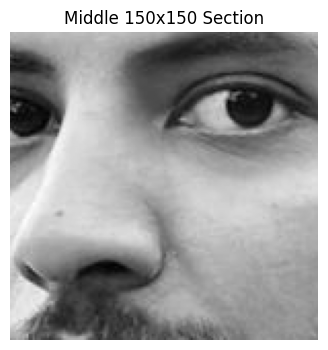

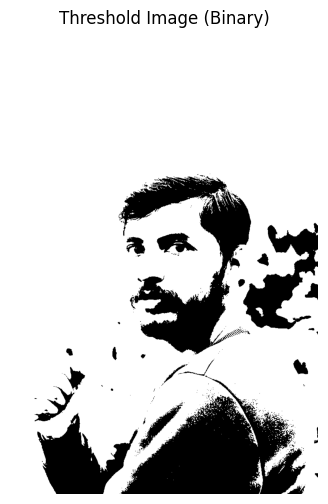

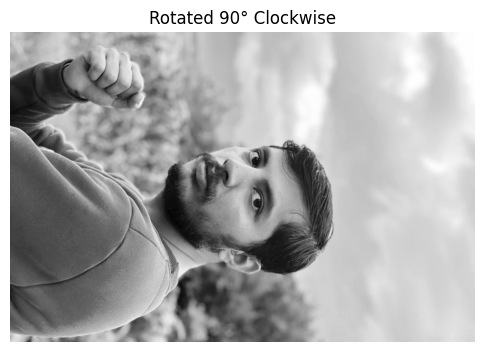

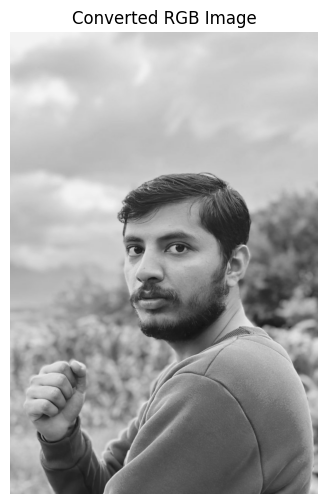

In [9]:
# Exercise 2: Grayscale Image Processing

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO

# ------------------ LOAD IMAGE FROM URL ------------------
url = "https://i.imgur.com/iyjjBpF.jpeg"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

if response.status_code == 200:
    try:
        # Load and convert to grayscale
        img = Image.open(BytesIO(response.content)).convert("L")
        img_array = np.array(img)

        # ------------------ TASK 1: DISPLAY GRAYSCALE IMAGE ------------------
        plt.figure(figsize=(6,6))
        plt.imshow(img_array, cmap='gray')
        plt.title("Grayscale Image")
        plt.axis('off')
        plt.show()

        # ------------------ TASK 2: MIDDLE 150x150 SECTION ------------------
        h, w = img_array.shape
        center_h, center_w = h // 2, w // 2

        middle = img_array[
            center_h - 75:center_h + 75,
            center_w - 75:center_w + 75
        ]

        plt.figure(figsize=(4,4))
        plt.imshow(middle, cmap='gray')
        plt.title("Middle 150x150 Section")
        plt.axis('off')
        plt.show()

        # ------------------ TASK 3: APPLY THRESHOLD ------------------
        threshold_img = img_array.copy()
        threshold_img[threshold_img < 100] = 0
        threshold_img[threshold_img >= 100] = 255

        plt.figure(figsize=(6,6))
        plt.imshow(threshold_img, cmap='gray')
        plt.title("Threshold Image (Binary)")
        plt.axis('off')
        plt.show()

        # ------------------ TASK 4: ROTATE 90° CLOCKWISE ------------------
        rotated = np.rot90(img_array, k=-1)

        plt.figure(figsize=(6,6))
        plt.imshow(rotated, cmap='gray')
        plt.title("Rotated 90° Clockwise")
        plt.axis('off')
        plt.show()

        # ------------------ TASK 5: CONVERT TO RGB ------------------
        rgb_img = np.stack((img_array,)*3, axis=-1)

        plt.figure(figsize=(6,6))
        plt.imshow(rgb_img)
        plt.title("Converted RGB Image")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print("Error:", e)
else:
    print("Failed to fetch image. Status code:", response.status_code)

Original image shape: (1200, 800)
Standardized data shape: (1200, 800)
Covariance matrix shape: (800, 800)


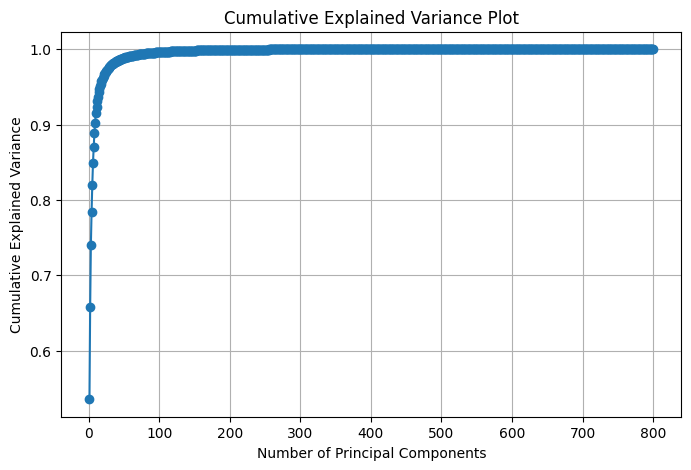

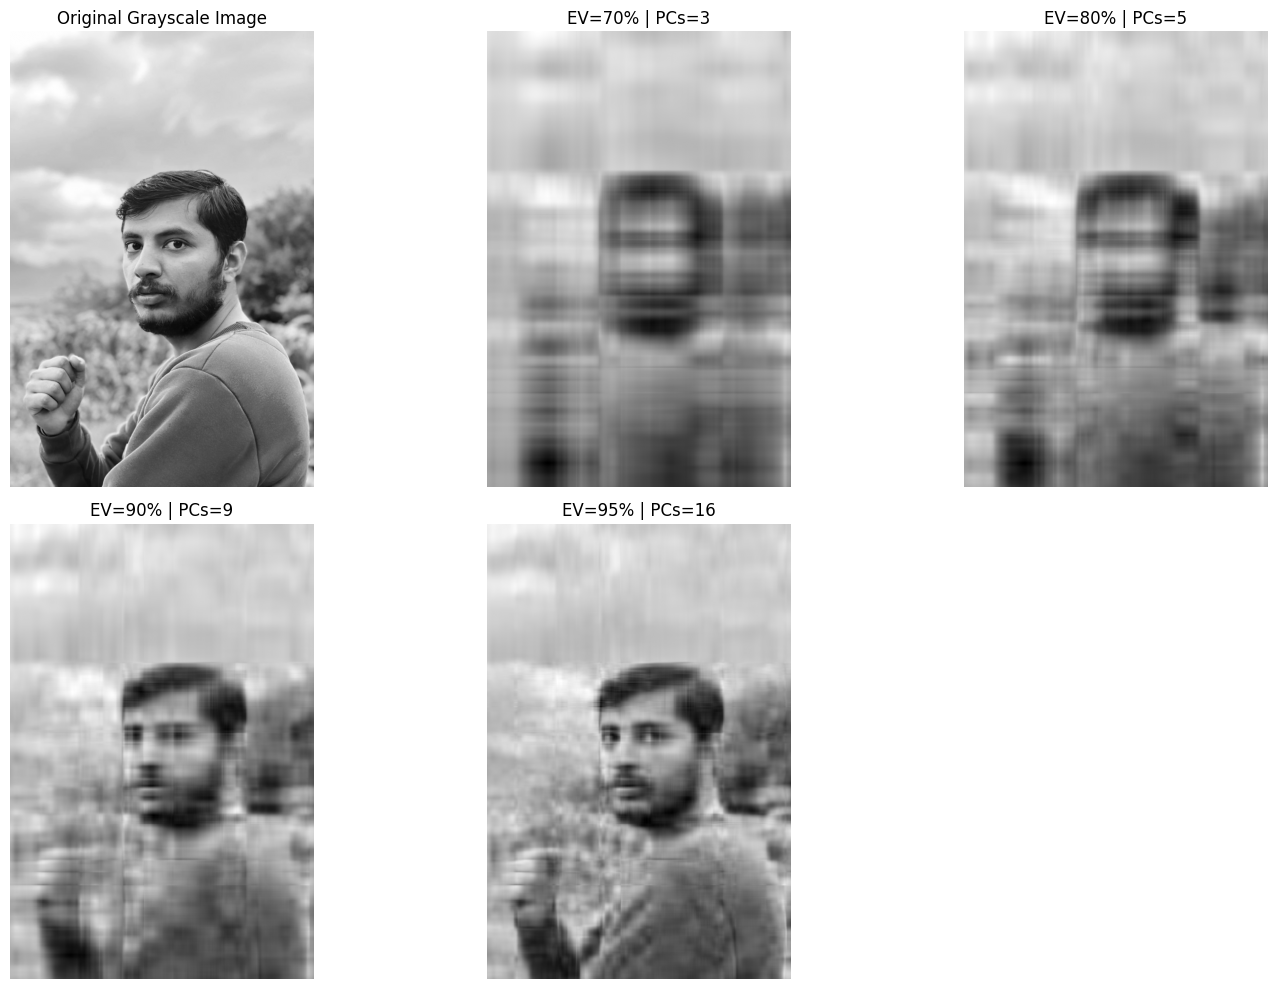


PCA Reconstruction Summary:
Explained Variance: 0.70, Principal Components: 3, MSE: 597.9545
Explained Variance: 0.80, Principal Components: 5, MSE: 441.4536
Explained Variance: 0.90, Principal Components: 9, MSE: 235.8369
Explained Variance: 0.95, Principal Components: 16, MSE: 125.4189


In [10]:
# Exercise 3: Image Compression and Decompression using PCA (from scratch)

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO

# ------------------ LOAD IMAGE FROM URL ------------------
url = "https://i.imgur.com/iyjjBpF.jpeg"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
if response.status_code != 200:
    raise Exception(f"Failed to fetch image. Status code: {response.status_code}")

img = Image.open(BytesIO(response.content)).convert("L")   # convert to grayscale
img_array = np.array(img, dtype=np.float64)

# Optional: resize if image is very large, to keep PCA faster
# img = img.resize((256, 256))
# img_array = np.array(img, dtype=np.float64)

print("Original image shape:", img_array.shape)

# ------------------ STEP 1: LOAD AND PREPARE DATA ------------------
# Treat each row as one sample, each column as one feature
X = img_array.copy()

# Center / standardize data
mean_vec = np.mean(X, axis=0)
std_vec = np.std(X, axis=0)

# Avoid division by zero
std_vec[std_vec == 0] = 1

X_std = (X - mean_vec) / std_vec

# Covariance matrix
cov_matrix = np.cov(X_std, rowvar=False)

print("Standardized data shape:", X_std.shape)
print("Covariance matrix shape:", cov_matrix.shape)

# ------------------ STEP 2: EIGEN DECOMPOSITION ------------------
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

# Explained variance ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.grid(True)
plt.show()

# ------------------ STEP 3: RECONSTRUCTION FUNCTION ------------------
def reconstruct_image_pca(X_std, eigenvectors, cumulative_variance, threshold, mean_vec, std_vec):
    """
    Reconstruct image using PCA components selected by explained variance threshold.

    Parameters:
        X_std (ndarray): Standardized image data.
        eigenvectors (ndarray): Sorted eigenvectors.
        cumulative_variance (ndarray): Cumulative explained variance values.
        threshold (float): Explained variance threshold, e.g. 0.80
        mean_vec (ndarray): Column means of original image data.
        std_vec (ndarray): Column standard deviations of original image data.

    Returns:
        reconstructed (ndarray): Reconstructed image
        k (int): Number of principal components used
    """
    k = np.argmax(cumulative_variance >= threshold) + 1
    pcs = eigenvectors[:, :k]

    # Transform to lower dimension
    X_reduced = np.dot(X_std, pcs)

    # Reconstruct standardized data
    X_reconstructed_std = np.dot(X_reduced, pcs.T)

    # Convert back to original scale
    reconstructed = (X_reconstructed_std * std_vec) + mean_vec

    return reconstructed, k

# ------------------ STEP 4: EXPERIMENTS WITH FOUR DIFFERENT VALUES ------------------
thresholds = [0.70, 0.80, 0.90, 0.95]
reconstructed_results = []

for t in thresholds:
    recon, k = reconstruct_image_pca(X_std, eigenvectors, cumulative_variance, t, mean_vec, std_vec)
    recon = np.clip(recon, 0, 255)
    reconstructed_results.append((t, k, recon))

# ------------------ STEP 5: DISPLAY RESULTS ------------------
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_array, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')

for i, (t, k, recon) in enumerate(reconstructed_results, start=2):
    plt.subplot(2, 3, i)
    plt.imshow(recon, cmap='gray')
    plt.title(f"EV={int(t*100)}% | PCs={k}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# ------------------ STEP 6: EVALUATION ------------------
print("\nPCA Reconstruction Summary:")
for t, k, recon in reconstructed_results:
    mse = np.mean((img_array - recon) ** 2)
    print(f"Explained Variance: {t:.2f}, Principal Components: {k}, MSE: {mse:.4f}")